# fMRI Reliability Pipeline
- Designed to parametrically analyze fMRI files to identify which pipelines produce the most robust results.

In [43]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

In [44]:
df = pd.read_csv('coordinatesAll.csv')
df.head()

,filename,filepath,subject,session,task,sequence_type,target,clustRegion,clustMask,X,Y,Z
0,068.04.rest.se.errts.targ.network.fisher.clust...,/cbica/projects/nbthetaconn/pipeline/results/0...,68,4,rest,se,network,ldlpfc,orig,47.0,-23.0,41.0
1,068.02.rest.me.errts.targ.network.fisher.clust...,/cbica/projects/nbthetaconn/pipeline/results/0...,68,2,rest,me,network,ldlpfc,dilate_5,23.0,-45.0,39.0
2,068.04.rest.me.errts.targ.seed.fisher.clust.ld...,/cbica/projects/nbthetaconn/pipeline/results/0...,68,4,rest,me,seed,ldlpfc,erode_1,39.0,-37.0,33.0
3,068.01.rest.se.errts.targ.network.fisher.clust...,/cbica/projects/nbthetaconn/pipeline/results/0...,68,1,rest,se,network,ldlpfc,erode_1,49.0,-23.0,33.0
4,068.03.rest.me.errts.targ.network.fisher.clust...,/cbica/projects/nbthetaconn/pipeline/results/0...,68,3,rest,me,network,ldlpfc,orig,49.0,-21.0,41.0


In [45]:
# Group by subject and each experimental condition
grouping_vars = ['subject', 'target', 'clustMask', 'sequence_type']

subjVec = df['subject'].unique()
targetVec = df['target'].unique()
cMaskVec = df['clustMask'].unique()
seqTypeVec = df['sequence_type'].unique()
combinations = list(itertools.product(subjVec, targetVec, cMaskVec, seqTypeVec))

# Put into pandas dataframe
combodf = pd.DataFrame(combinations, columns=['subject', 'target', 'clustMask', 'sequence_type'])
combodf.head()

,subject,target,clustMask,sequence_type
0,68,network,orig,se
1,68,network,orig,me
2,68,network,dilate_5,se
3,68,network,dilate_5,me
4,68,network,erode_1,se


In [47]:
results = []

for idx, combo in enumerate(combinations):
    df_filt = df[
        (df['subject'] == combo[0]) & 
        (df['target'] == combo[1]) & 
        (df['clustMask'] == combo[2]) & 
        (df['sequence_type'] == combo[3])
    ]
    meanDist = round(pdist(df_filt[['X','Y','Z']], metric='euclidean').mean(),2)
    results.append(meanDist)

print(results)

[np.float64(3.52), np.float64(3.0), np.float64(15.76), np.float64(27.82), np.float64(8.6), np.float64(8.76), np.float64(13.76), np.float64(16.61), np.float64(24.25), np.float64(21.6), np.float64(9.44), np.float64(8.19), np.float64(21.06), np.float64(17.26), np.float64(29.2), np.float64(35.63), np.float64(3.0), np.float64(10.42), np.float64(22.15), np.float64(10.9), np.float64(23.48), np.float64(26.87), np.float64(9.49), np.float64(7.64), np.float64(14.28), np.float64(18.79), np.float64(19.93), np.float64(19.65), np.float64(5.74), np.float64(10.03), np.float64(16.31), np.float64(16.47), np.float64(35.16), np.float64(13.91), np.float64(11.27), np.float64(7.78), np.float64(7.71), np.float64(16.3), np.float64(2.36), np.float64(32.12), np.float64(13.95), np.float64(10.14), np.float64(8.4), np.float64(13.09), np.float64(18.0), np.float64(26.65), np.float64(6.87), np.float64(6.83), np.float64(12.93), np.float64(18.13), np.float64(23.34), np.float64(21.38), np.float64(3.74), np.float64(3.61), 

In [48]:
combodf['mean_distance'] = results
print(combodf)

      subject   target clustMask sequence_type  mean_distance
0          68  network      orig            se           3.52
1          68  network      orig            me           3.00
2          68  network  dilate_5            se          15.76
3          68  network  dilate_5            me          27.82
4          68  network   erode_1            se           8.60
...       ...      ...       ...           ...            ...
1219       73     seed      orig            me          16.84
1220       73     seed  dilate_5            se          32.75
1221       73     seed  dilate_5            me          21.72
1222       73     seed   erode_1            se           9.37
1223       73     seed   erode_1            me          15.09

[1224 rows x 5 columns]


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

grouping_vars = ['target' , 'clustMask', 'sequence']
for idx, var in enumerate(grouping_vars):
    # Violin plot
    parts = axes[idx].violinplot(
        [combodf[combodf[var] == val]['mean_distance'].dropna() 
         for val in combodf[var].unique()],
        positions=range(len(combodf[var].unique())),
        showmeans=True,
        showmedians=True
    )
    
    # Set labels
    axes[idx].set_xticks(range(len(combodf[var].unique())))
    axes[idx].set_xticklabels(combodf[var].unique(), rotation=45)
    axes[idx].set_title(f'Distribution by {var}')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Mean Pairwise Distance')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# combodf = combodf[combodf['clustMask'] != 'dilate_5']

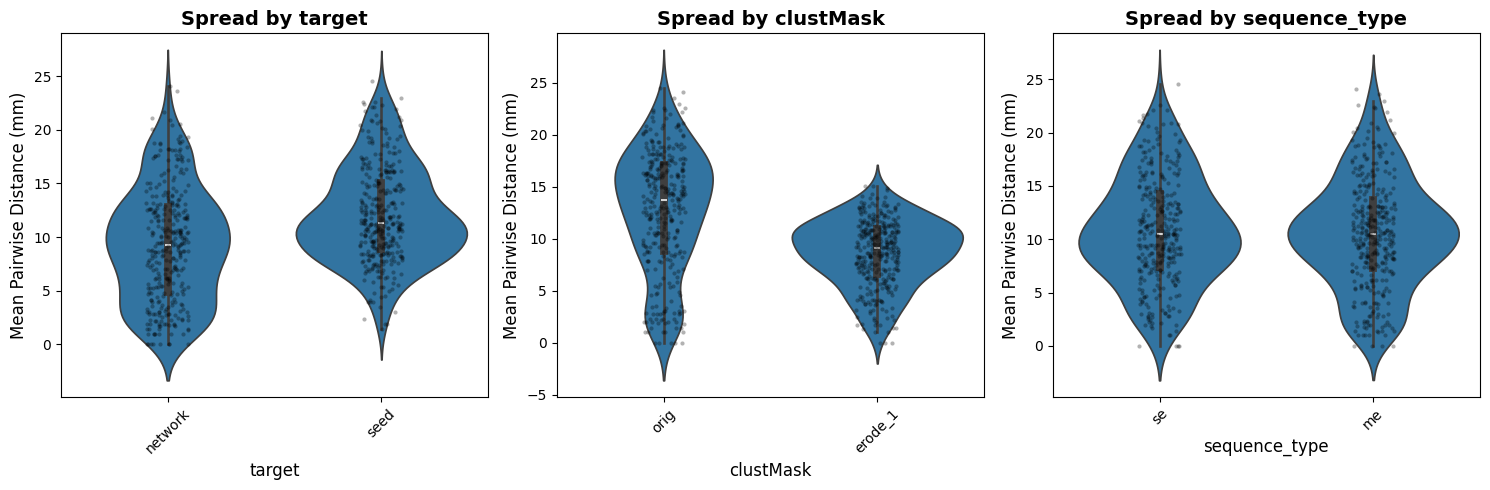

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
grouping_vars = ['target', 'clustMask', 'sequence_type']

for idx, var in enumerate(grouping_vars):
    # Create violin plot
    sns.violinplot(data=combodf, x=var, y='mean_distance', ax=axes[idx], 
                   inner='box')  # Shows quartiles inside
    
    # Add individual points
    sns.stripplot(data=combodf, x=var, y='mean_distance', ax=axes[idx],
                  color='black', alpha=0.3, size=3)
    
    axes[idx].set_title(f'Spread by {var}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel(var, fontsize=12)
    axes[idx].set_ylabel('Mean Pairwise Distance (mm)', fontsize=12)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

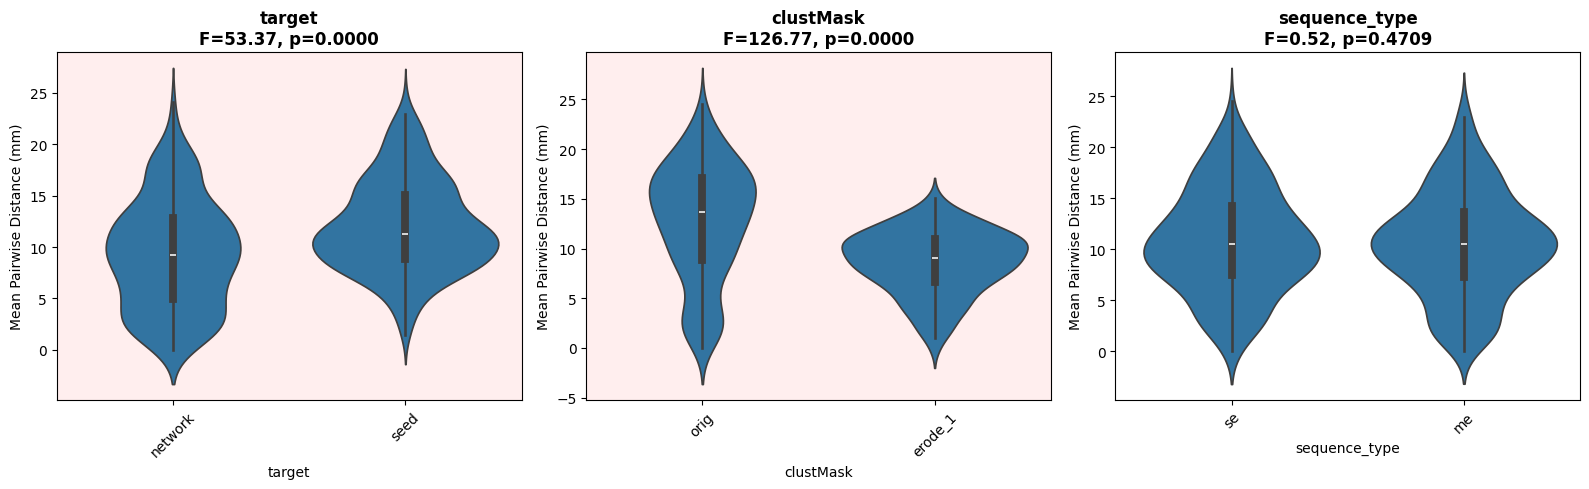

In [ ]:
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, var in enumerate(grouping_vars):
    # Violin plot
    sns.violinplot(data=combodf, x=var, y='mean_distance', ax=axes[idx])
    
    # Perform ANOVA
    groups = [combodf[combodf[var] == val]['mean_distance'].dropna() 
              for val in combodf[var].unique()]
    f_stat, p_val = f_oneway(*groups)
    
    # Add title with statistics
    axes[idx].set_title(f'{var}\nF={f_stat:.2f}, p={p_val:.4f}', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Mean Pairwise Distance (mm)')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Highlight significance
    if p_val < 0.05:
        axes[idx].set_facecolor("#f0eeff")  # Light red background

plt.tight_layout()
plt.show()